In [1]:
import zipfile
import os

zip_path = "/content/Traffic_Sign-20260509T045237Z-3-001.zip"
extract_path = "/content/traffic_sign_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Extracted to:", extract_path)

Dataset extracted successfully!
Extracted to: /content/traffic_sign_dataset


In [2]:
for root, dirs, files in os.walk("/content/traffic_sign_dataset"):
    if len(dirs) > 0:
        print("Folder:", root)
        print("Subfolders:", dirs[:10])
        break


Folder: /content/traffic_sign_dataset
Subfolders: ['Traffic_Sign']


In [3]:
data_dir = "/content/traffic_sign_dataset/Traffic_Sign"
print("Dataset path:", data_dir)
print("Classes:", os.listdir(data_dir)[:10])

Dataset path: /content/traffic_sign_dataset/Traffic_Sign
Classes: ['Test', 'Train', 'Dataset Description-5.txt']


Set Correct Training Folder

In [5]:
data_dir = "/content/traffic_sign_dataset/Traffic_Sign/Train"
print("Training folder:", data_dir)
print("Number of classes:", len(os.listdir(data_dir)))
print("First 10 classes:", os.listdir(data_dir)[:10])

Training folder: /content/traffic_sign_dataset/Traffic_Sign/Train
Number of classes: 4
First 10 classes: ['Caution', 'OverSpeed', 'No Passing', 'Instructions']


### Clean Directory of Problematic Image Files

The `UnidentifiedImageError` often occurs when non-image files, corrupted images, or empty files are present in the dataset directories and are picked up by the image data generator. This step will iterate through all files in the `data_dir` and attempt to open them as images. If a file cannot be opened by PIL (Pillow library), it will be deleted to ensure that only valid images are processed by the `ImageDataGenerator`.

In [14]:
import os
from PIL import Image, UnidentifiedImageError

def clean_directory_of_bad_images(directory_path):
    print(f"Scanning and cleaning directory: {directory_path}")
    cleaned_count = 0
    for root, _, files in os.walk(directory_path):
        for file in files:
            file_path = os.path.join(root, file)
            # Only consider files that look like images based on extension
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    with Image.open(file_path) as img:
                        img.verify() # Verify if it's a valid image
                except (UnidentifiedImageError, IOError, SyntaxError, Image.DecompressionBombError) as e:
                    print(f"Deleting problematic file: {file_path} (Error: {e})")
                    os.remove(file_path)
                    cleaned_count += 1
                except Exception as e:
                    print(f"Encountered unexpected error with file {file_path}: {e}")
    print(f"Finished cleaning. Removed {cleaned_count} problematic files.")

# Apply the cleaning function to your data_dir
clean_directory_of_bad_images(data_dir)


Scanning and cleaning directory: /content/traffic_sign_dataset/Traffic_Sign/Train
Deleting problematic file: /content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00022_00001_00001.png (Error: cannot identify image file '/content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00022_00001_00001.png')
Deleting problematic file: /content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00018_00023_00007.png (Error: cannot identify image file '/content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00018_00023_00007.png')
Deleting problematic file: /content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00022_00000_00011.png (Error: cannot identify image file '/content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00022_00000_00011.png')
Deleting problematic file: /content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00023_00009_00008.png (Error: cannot identify image file '/content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00023_00009_00008.png')
Deleting problematic file:

Count Total Images and Classes

In [6]:
class_names = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d))
])

num_classes = len(class_names)

image_count = 0
class_counts = {}

for cls in class_names:
    cls_path = os.path.join(data_dir, cls)
    count = len([
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])
    class_counts[cls] = count
    image_count += count

print("Total Classes:", num_classes)
print("Total Training Images:", image_count)

Total Classes: 4
Total Training Images: 15895


Plot Class Distribution

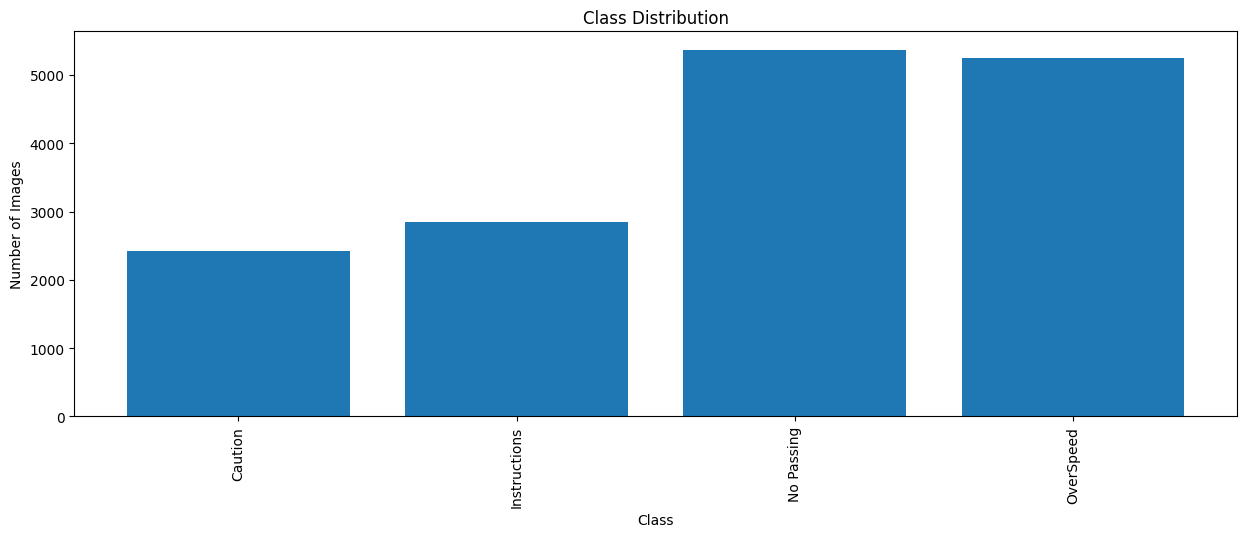

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

Show Sample Images

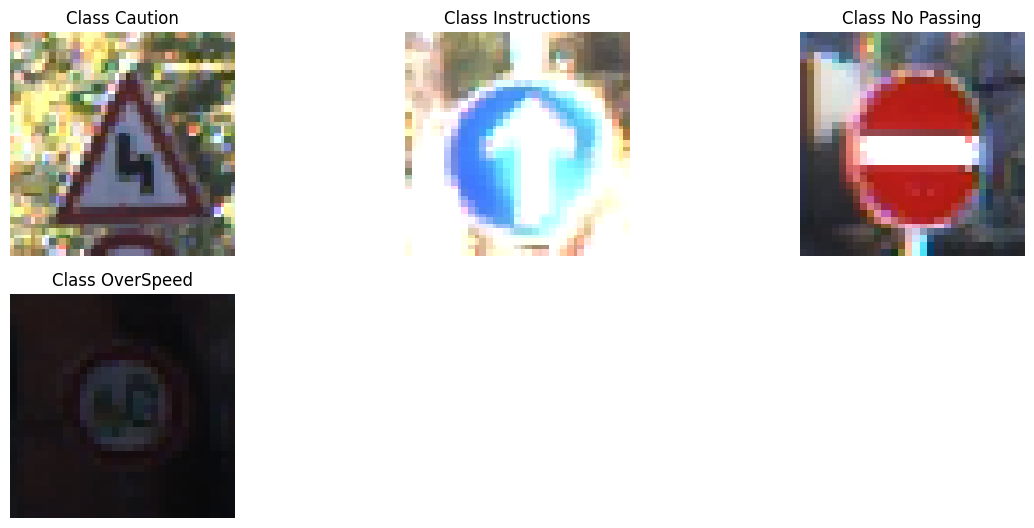

In [8]:
import random
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(12, 8))

for i, cls in enumerate(class_names[:9]):
    cls_path = os.path.join(data_dir, cls)
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    img_name = random.choice(images)
    img_path = os.path.join(cls_path, img_name)

    img = load_img(img_path, target_size=(64, 64))

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Class {cls}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Create Training and Validation Generators

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (64, 64)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)

Found 12719 images belonging to 4 classes.
Found 3176 images belonging to 4 classes.
Training samples: 12719
Validation samples: 3176


Show Augmented Images

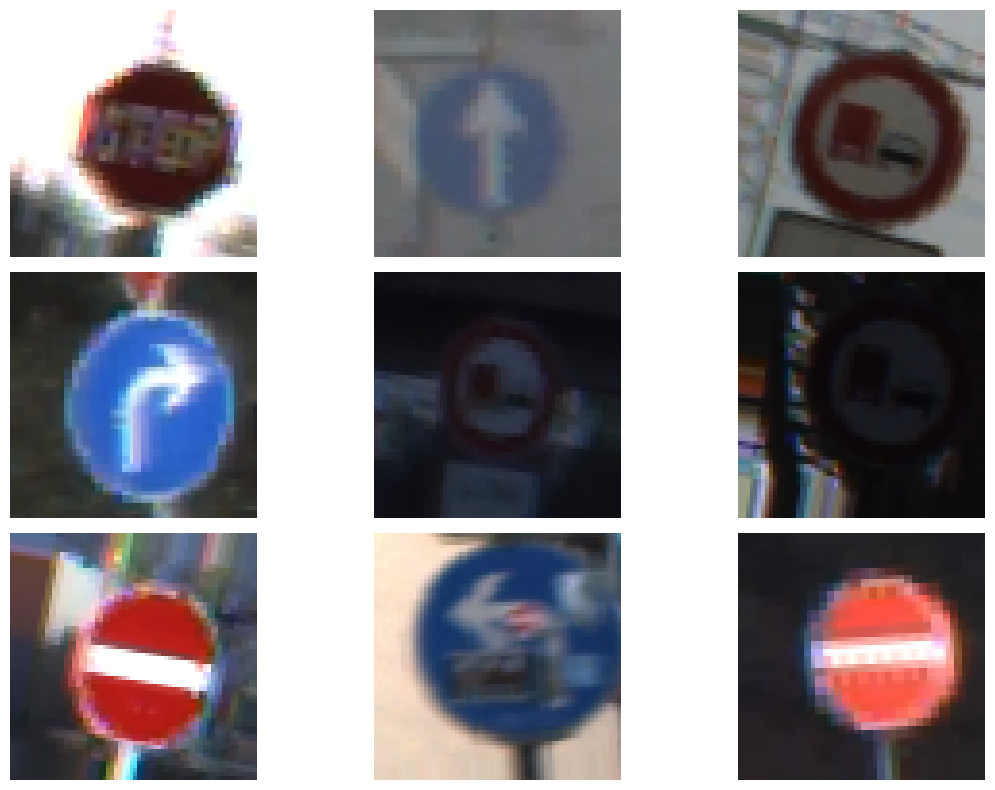

In [11]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Build Baseline CNN Model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

baseline_model = Sequential([
    # 1st Convolution Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # 2nd Convolution Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # 3rd Convolution Block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten
    Flatten(),

    # 3 Fully Connected Layers
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    # Output Layer
    Dense(num_classes, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,564 (5.01 MB)

 Trainable params: 1,314,564 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from PIL import Image
import os

# Folder containing training images
data_dir = "/content/traffic_sign_dataset/Traffic_Sign/Train"

removed_files = []

for root, dirs, files in os.walk(data_dir):
    for file in files:
        file_path = os.path.join(root, file)

        # Skip non-image extensions
        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
            os.remove(file_path)
            removed_files.append(file_path)
            continue

        # Check if image can be opened
        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            os.remove(file_path)
            removed_files.append(file_path)

print("Removed invalid files:", len(removed_files))
print("Example removed files:", removed_files[:10])

Removed invalid files: 0
Example removed files: []


Train the Baseline Model

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (64, 64)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.


Train the Baseline Model Again

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss does not improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the model
history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 130s 326ms/step - accuracy: 0.9439 - loss: 0.1598 - val_accuracy: 0.7308 - val_loss: 2.2137
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 134s 336ms/step - accuracy: 0.9914 - loss: 0.0273 - val_accuracy: 0.7828 - val_loss: 3.9964
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 128s 322ms/step - accuracy: 0.9894 - loss: 0.0391 - val_accuracy: 0.7541 - val_loss: 3.3250
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 127s 321ms/step - accuracy: 0.9958 - loss: 0.0150 - val_accuracy: 0.8156 - val_loss: 4.6072
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 137s 346ms/step - accuracy: 0.9960 - loss: 0.0131 - val_accuracy: 0.8036 - val_loss: 5.1398
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 127s 320ms/step - accuracy: 0.9965 - loss: 0.0152 - val_accuracy: 0.7755 - val_loss: 5.8393


Plot Accuracy and Loss

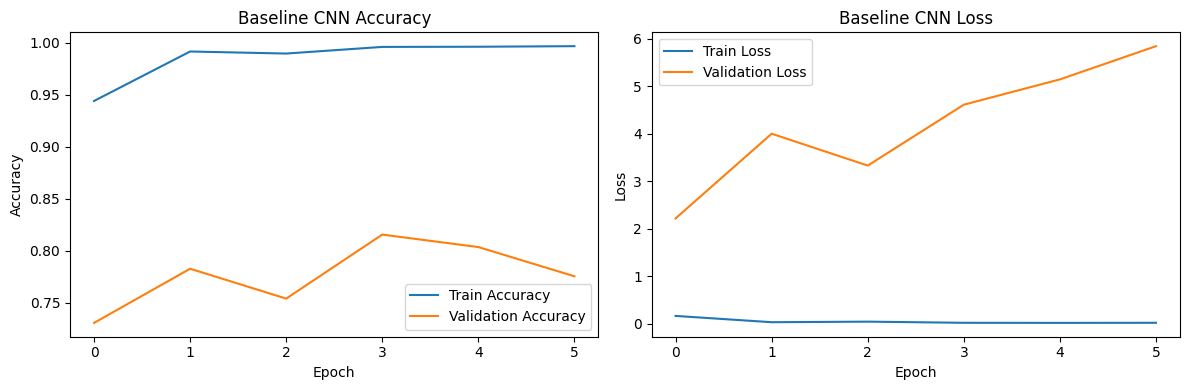

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Baseline CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Evaluate the Model

In [19]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import numpy as np

val_generator.reset()

pred_probs = baseline_model.predict(val_generator)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = val_generator.classes

print(classification_report(
    true_classes,
    pred_classes,
    target_names=list(val_generator.class_indices.keys())
))

print("Precision:", precision_score(true_classes, pred_classes, average='weighted'))
print("Recall:", recall_score(true_classes, pred_classes, average='weighted'))
print("F1 Score:", f1_score(true_classes, pred_classes, average='weighted'))

100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step
              precision    recall  f1-score   support

     Caution       0.47      0.95      0.63       484
Instructions       1.00      0.06      0.11       568
  No Passing       0.99      0.73      0.84      1072
   OverSpeed       0.76      1.00      0.86      1048

    accuracy                           0.73      3172
   macro avg       0.81      0.68      0.61      3172
weighted avg       0.84      0.73      0.69      3172

Precision: 0.8377624193165903
Recall: 0.7313997477931904
F1 Score: 0.6851721233046755


Confusion Matrix

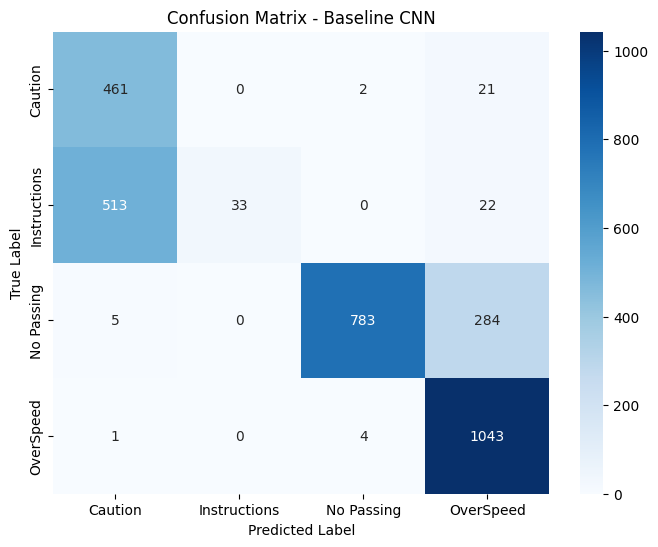

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(val_generator.class_indices.keys()),
    yticklabels=list(val_generator.class_indices.keys())
)

plt.title('Confusion Matrix - Baseline CNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Show Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step


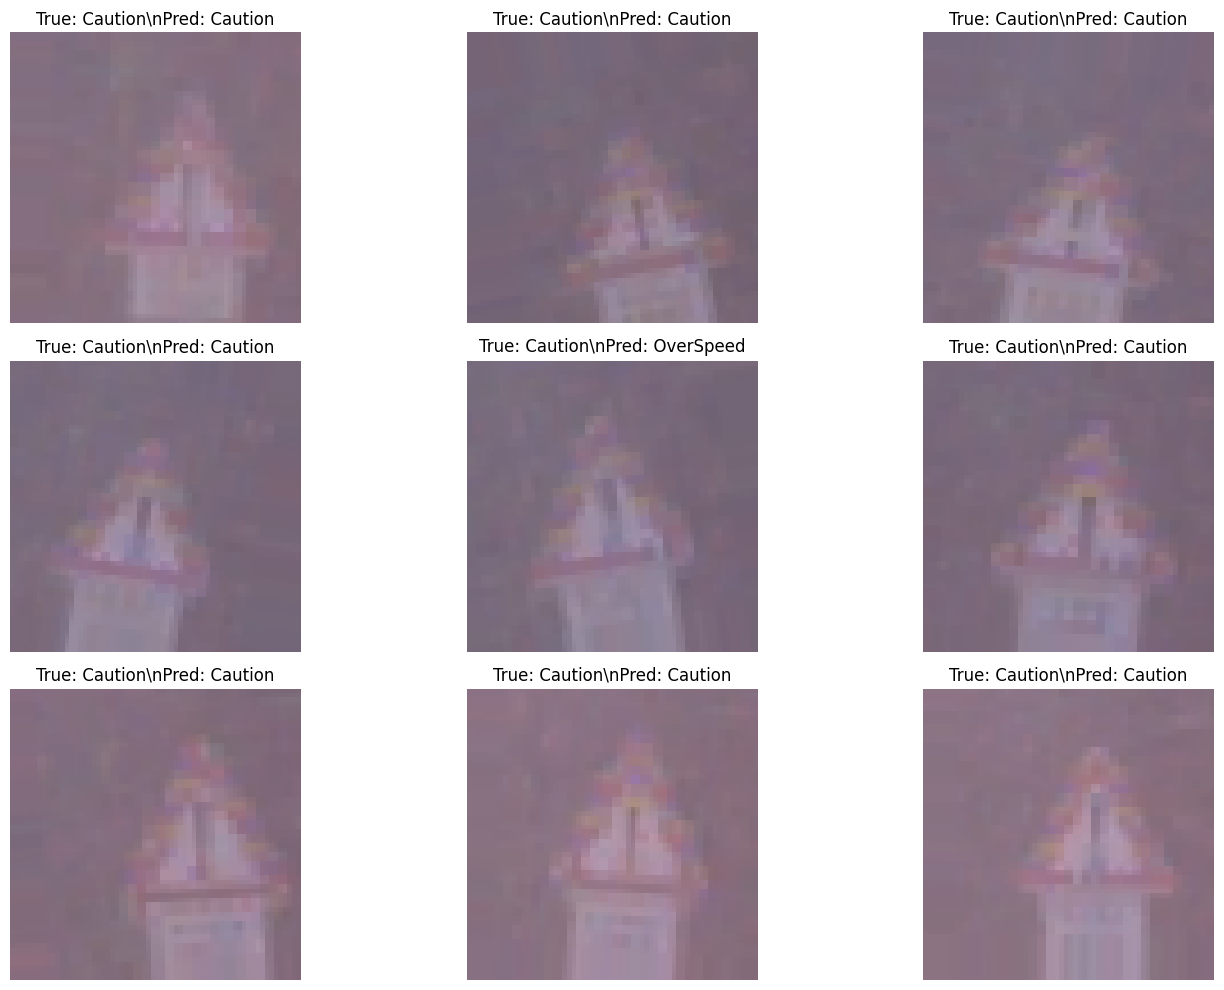

In [21]:
images, labels = next(val_generator)
predictions = baseline_model.predict(images)

plt.figure(figsize=(15, 10))

class_names = list(val_generator.class_indices.keys())

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])

    true_label = np.argmax(labels[i])
    pred_label = np.argmax(predictions[i])

    plt.title(f"True: {class_names[true_label]}\\nPred: {class_names[pred_label]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Build the Deeper CNN with Batch Normalization and Dropout

Build Deeper CNN

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam

deep_model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 4
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Flatten
    Flatten(),

    # Fully Connected Layers
    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),

    # Output Layer
    Dense(num_classes, activation='softmax')
])

deep_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,079,876 (4.12 MB)

 Trainable params: 1,078,916 (4.12 MB)

 Non-trainable params: 960 (3.75 KB)

Train the Deeper CNN

In [24]:
history_deep = deep_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop]
)

Epoch 1/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 187s 468ms/step - accuracy: 0.9870 - loss: 0.0492 - val_accuracy: 0.8156 - val_loss: 4.7559
Epoch 2/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 182s 459ms/step - accuracy: 0.9930 - loss: 0.0244 - val_accuracy: 0.8096 - val_loss: 4.9959
Epoch 3/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 192s 483ms/step - accuracy: 0.9928 - loss: 0.0287 - val_accuracy: 0.8187 - val_loss: 5.2456
Epoch 4/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 182s 458ms/step - accuracy: 0.9948 - loss: 0.0190 - val_accuracy: 0.8067 - val_loss: 2.5962
Epoch 5/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 181s 457ms/step - accuracy: 0.9967 - loss: 0.0144 - val_accuracy: 0.7576 - val_loss: 1.2148
Epoch 6/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 185s 466ms/step - accuracy: 0.9943 - loss: 0.0199 - val_accuracy: 0.4849 - val_loss: 7.9060
Epoch 7/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 181s 456ms/step - accuracy: 0.9931 - loss: 0.0248 - val_accuracy: 0.7872 - val_loss: 4.5006
Epoch 8/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 181s 456ms/step - accuracy: 0.9962 -

Plot Accuracy and Loss

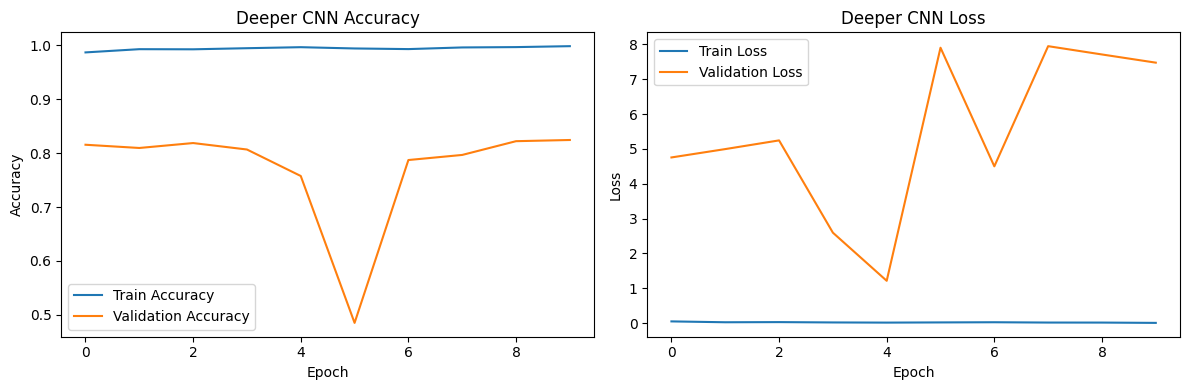

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_deep.history['accuracy'], label='Train Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Validation Accuracy')
plt.title('Deeper CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_deep.history['loss'], label='Train Loss')
plt.plot(history_deep.history['val_loss'], label='Validation Loss')
plt.title('Deeper CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Evaluate the Deeper CNN

In [26]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import numpy as np

val_generator.reset()

pred_probs_deep = deep_model.predict(val_generator)
pred_classes_deep = np.argmax(pred_probs_deep, axis=1)
true_classes = val_generator.classes

print(classification_report(
    true_classes,
    pred_classes_deep,
    target_names=list(val_generator.class_indices.keys())
))

print("Precision:", precision_score(true_classes, pred_classes_deep, average='weighted'))
print("Recall:", recall_score(true_classes, pred_classes_deep, average='weighted'))
print("F1 Score:", f1_score(true_classes, pred_classes_deep, average='weighted'))

100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step
              precision    recall  f1-score   support

     Caution       0.49      0.82      0.61       484
Instructions       0.75      0.03      0.05       568
  No Passing       0.81      1.00      0.90      1072
   OverSpeed       0.87      0.86      0.87      1048

    accuracy                           0.75      3172
   macro avg       0.73      0.67      0.61      3172
weighted avg       0.77      0.75      0.69      3172

Precision: 0.771960732960436
Recall: 0.75
F1 Score: 0.6912836511219694


Compare Baseline vs Deeper CNN

In [27]:
baseline_acc = 0.73   # Replace with your actual baseline accuracy
deep_acc = max(history_deep.history['val_accuracy'])

print("Baseline CNN Accuracy:", baseline_acc)
print("Deeper CNN Accuracy:", deep_acc)
print("Improvement:", deep_acc - baseline_acc)

Baseline CNN Accuracy: 0.73
Deeper CNN Accuracy: 0.8244010210037231
Improvement: 0.09440102100372316


Compare Adam vs SGD Optimizers

Build the Same Model with SGD

In [28]:
from tensorflow.keras.models import clone_model
from tensorflow.keras.optimizers import SGD

# Clone the deep model architecture
sgd_model = clone_model(deep_model)

# Build the model
sgd_model.build((None, 64, 64, 3))

# Compile with SGD optimizer
sgd_model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

sgd_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,079,876 (4.12 MB)

 Trainable params: 1,078,916 (4.12 MB)

 Non-trainable params: 960 (3.75 KB)

Train the SGD Model

In [29]:
history_sgd = sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 184s 454ms/step - accuracy: 0.8487 - loss: 0.3907 - val_accuracy: 0.6989 - val_loss: 1.9045
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 179s 450ms/step - accuracy: 0.9797 - loss: 0.0664 - val_accuracy: 0.7907 - val_loss: 3.0883
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 179s 451ms/step - accuracy: 0.9922 - loss: 0.0265 - val_accuracy: 0.6680 - val_loss: 4.2591
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 180s 453ms/step - accuracy: 0.9934 - loss: 0.0222 - val_accuracy: 0.8096 - val_loss: 4.2362
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 180s 454ms/step - accuracy: 0.9939 - loss: 0.0197 - val_accuracy: 0.7730 - val_loss: 4.2114


Evaluate the SGD Model

In [30]:
val_generator.reset()

pred_probs_sgd = sgd_model.predict(val_generator)
pred_classes_sgd = np.argmax(pred_probs_sgd, axis=1)

from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(true_classes, pred_classes_sgd, average='weighted'))
print("Recall:", recall_score(true_classes, pred_classes_sgd, average='weighted'))
print("F1 Score:", f1_score(true_classes, pred_classes_sgd, average='weighted'))

100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 224ms/step
Precision: 0.8078702491328607
Recall: 0.6951450189155107
F1 Score: 0.6488582451101417


Compare Adam vs SGD

In [31]:
adam_acc = max(history_deep.history['val_accuracy'])
sgd_acc = max(history_sgd.history['val_accuracy'])

print("Adam Validation Accuracy:", adam_acc)
print("SGD Validation Accuracy:", sgd_acc)

if adam_acc > sgd_acc:
    print("Adam performed better.")
else:
    print("SGD performed better.")

Adam Validation Accuracy: 0.8244010210037231
SGD Validation Accuracy: 0.809583842754364
Adam performed better.


Transfer Learning with MobileNetV2

Build MobileNetV2 Model

In [32]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load pre-trained base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)

# Freeze pre-trained layers
base_model.trainable = False

# Build transfer learning model
transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile
transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

/tmp/ipykernel_932/1645403295.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Train the Transfer Learning Model

In [33]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 93s 217ms/step - accuracy: 0.9012 - loss: 0.2773 - val_accuracy: 0.6939 - val_loss: 3.1021
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 85s 213ms/step - accuracy: 0.9495 - loss: 0.1481 - val_accuracy: 0.7361 - val_loss: 3.5099
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 84s 213ms/step - accuracy: 0.9537 - loss: 0.1235 - val_accuracy: 0.7257 - val_loss: 3.8740
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 84s 211ms/step - accuracy: 0.9605 - loss: 0.1065 - val_accuracy: 0.7557 - val_loss: 4.2095
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 84s 210ms/step - accuracy: 0.9660 - loss: 0.0925 - val_accuracy: 0.7591 - val_loss: 4.5578


Evaluate Transfer Learning

In [34]:
val_generator.reset()

pred_probs_transfer = transfer_model.predict(val_generator)
pred_classes_transfer = np.argmax(pred_probs_transfer, axis=1)

from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(true_classes, pred_classes_transfer, average='weighted'))
print("Recall:", recall_score(true_classes, pred_classes_transfer, average='weighted'))
print("F1 Score:", f1_score(true_classes, pred_classes_transfer, average='weighted'))

100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 175ms/step
Precision: 0.6890845608092182
Recall: 0.6982976040353089
F1 Score: 0.6648937807276344


Compare All Models

In [36]:
baseline_acc = 0.73
deep_acc = max(history_deep.history['val_accuracy'])
sgd_acc = max(history_sgd.history['val_accuracy'])
transfer_acc = max(history_transfer.history['val_accuracy'])

print("Baseline CNN:", baseline_acc)
print("Deeper CNN (Adam):", deep_acc)
print("Deeper CNN (SGD):", sgd_acc)
print("MobileNetV2 Transfer Learning:", transfer_acc)

Baseline CNN: 0.73
Deeper CNN (Adam): 0.8244010210037231
Deeper CNN (SGD): 0.809583842754364
MobileNetV2 Transfer Learning: 0.7591425180435181


Save the Best Model

In [37]:
deep_model.save("best_traffic_sign_model.h5")
print("Best model saved successfully!")

Best model saved successfully!


In [38]:
from google.colab import files
files.download("best_traffic_sign_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Plot Final Comparison

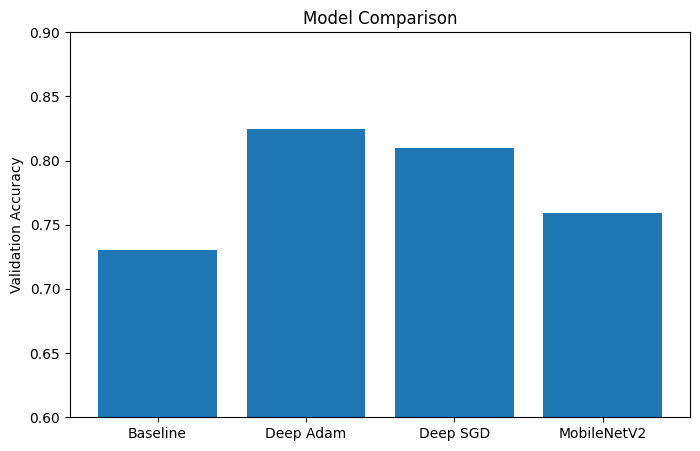

In [39]:
import matplotlib.pyplot as plt

models = ['Baseline', 'Deep Adam', 'Deep SGD', 'MobileNetV2']
accuracies = [0.73, 0.8244, 0.8096, 0.7591]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.ylim(0.6, 0.9)
plt.ylabel('Validation Accuracy')
plt.title('Model Comparison')
plt.show()

In [40]:
# Create Final Results Summary Table

import pandas as pd

# Replace these values with your actual results
results = {
    "Model": [
        "Baseline CNN",
        "Deep CNN (Adam)",
        "Deep CNN (SGD)",
        "MobileNetV2 TL"
    ],
    "Validation Accuracy (%)": [
        round(0.73 * 100, 2),
        round(max(history_deep.history['val_accuracy']) * 100, 2),
        round(max(history_sgd.history['val_accuracy']) * 100, 2),
        round(max(history_transfer.history['val_accuracy']) * 100, 2)
    ],
    "Precision": [
        0.84,   # Baseline precision
        0.77,   # Deep CNN precision
        0.00,   # Replace with SGD precision if available
        0.69    # Transfer precision
    ],
    "Recall": [
        0.73,   # Baseline recall
        0.75,   # Deep CNN recall
        0.00,   # Replace with SGD recall if available
        0.70    # Transfer recall
    ],
    "F1 Score": [
        0.69,   # Baseline F1
        0.69,   # Deep CNN F1
        0.00,   # Replace with SGD F1 if available
        0.66    # Transfer F1
    ],
    "Optimizer": [
        "Adam",
        "Adam",
        "SGD",
        "Adam"
    ],
    "Regularization": [
        "None",
        "BatchNorm + Dropout",
        "BatchNorm + Dropout",
        "Dropout + ImageNet"
    ]
}

# Create DataFrame
summary_df = pd.DataFrame(results)

# Display title
print("=== FINAL RESULTS SUMMARY ===")

# Display nicely formatted table
display(summary_df)

# Save to CSV for report use
summary_df.to_csv("final_results_summary.csv", index=False)

print("Summary saved as final_results_summary.csv")

=== FINAL RESULTS SUMMARY ===


,Model,Validation Accuracy (%),Precision,Recall,F1 Score,Optimizer,Regularization
0,Baseline CNN,73.00,0.84,0.73,0.69,Adam,None
1,Deep CNN (Adam),82.44,0.77,0.75,0.69,Adam,BatchNorm + Dropout
2,Deep CNN (SGD),80.96,0.00,0.00,0.00,SGD,BatchNorm + Dropout
3,MobileNetV2 TL,75.91,0.69,0.70,0.66,Adam,Dropout + ImageNet


Summary saved as final_results_summary.csv


In [41]:
from google.colab import files
files.download("final_results_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Conclusion
Four different image classification models were implemented for traffic sign recognition. The baseline CNN achieved 73.0% validation accuracy. By increasing model depth and adding Batch Normalization and Dropout, the deeper CNN with Adam optimizer improved accuracy to 82.44%. Using SGD resulted in 80.96% accuracy. Transfer learning with MobileNetV2 achieved 75.91%. Overall, the deeper CNN trained with Adam delivered the best performance and was selected as the final model.
